In [208]:
import pandas as pd

import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler   
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, LassoCV, RidgeCV, ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

from sklearn.preprocessing import RobustScaler

from haversine import haversine, Unit

import warnings

In [209]:
warnings.filterwarnings("ignore")

In [210]:
### carga datos de dataset en dataframe
file_path= 'uber_fares.csv'

df = pd.read_csv(file_path)

In [211]:
### visualizacion de algunos datos
df.head()

,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


#### Contexto  
El proyecto trata sobre **Uber Inc.**, la compañía de taxis más grande del mundo. En este trabajo, nuestro objetivo es **predecir la tarifa de futuros viajes**.  

Uber brinda servicio a millones de clientes cada día, por lo que gestionar adecuadamente sus datos es clave para desarrollar nuevas estrategias de negocio y obtener mejores resultados.  

### Variables del conjunto de datos  

**Variables explicativas:**  
- **key**: identificador único de cada viaje.  
- **pickup_datetime**: fecha y hora en que se inició el viaje.  
- **passenger_count**: cantidad de pasajeros en el vehículo (dato ingresado por el conductor).  
- **pickup_longitude**: longitud del punto de inicio del viaje.  
- **pickup_latitude**: latitud del punto de inicio del viaje.  
- **dropoff_longitude**: longitud del punto de destino.  
- **dropoff_latitude**: latitud del punto de destino.  

**Variable objetivo (target):**  
- **fare_amount**: costo del viaje en dólares.  

In [212]:
### Columnas, ¿cuáles son variables numéricas y cuales variables categóricas?
df.columns

Index(['key', 'date', 'fare_amount', 'pickup_datetime', 'pickup_longitude',
       'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
       'passenger_count'],
      dtype='object')

In [213]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                200000 non-null  int64  
 1   date               200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


In [214]:
# Limpiar longitud  y latitud

# Filtro para encontrar coordenadas inválidas
coordenadas_invalidas = (
    (df['pickup_latitude'] < -90) | (df['pickup_latitude'] > 90) |
    (df['pickup_longitude'] < -180) | (df['pickup_longitude'] > 180) |
    (df['dropoff_latitude'] < -90) | (df['dropoff_latitude'] > 90) |
    (df['dropoff_longitude'] < -180) | (df['dropoff_longitude'] > 180)
)

# Muestra las filas que tienen al menos una coordenada incorrecta
print("Filas con coordenadas inválidas:")
#print(df[coordenadas_invalidas])
print(df[coordenadas_invalidas].count())

Filas con coordenadas inválidas:
key                  12
date                 12
fare_amount          12
pickup_datetime      12
pickup_longitude     12
pickup_latitude      12
dropoff_longitude    12
dropoff_latitude     12
passenger_count      12
dtype: int64


In [215]:
df= df[~coordenadas_invalidas].copy()

In [216]:
# Crear columna distancia
df['distancia_km'] = df.apply(
    lambda row: haversine(
        (row['pickup_latitude'], row['pickup_longitude']),
        (row['dropoff_latitude'], row['dropoff_longitude']),
        unit=Unit.KILOMETERS
    ),
    axis=1
)

In [217]:
df.head()

,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distancia_km
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1,1.683325
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1,2.457593
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1,5.036384
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3,1.661686
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5,4.475456


# Dividir datos de entrenamiento y testeo

In [218]:
x = df.drop('fare_amount', axis=1)
y = df['fare_amount']
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Analisis exploratorio de datos

In [219]:
X_train.describe()

,key,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distancia_km
count,1.599900e+05,159990.000000,159990.000000,159989.000000,159989.000000,159990.000000,159989.000000
mean,2.772714e+07,-72.481311,39.906820,-72.487486,39.909629,1.679505,20.764921
std,1.602099e+07,10.518721,6.163014,10.493263,6.154534,1.303397,381.919820
min,1.000000e+00,-93.824668,-74.015515,-75.458979,-74.015750,0.000000,0.000000
25%,1.383602e+07,-73.992075,40.734757,-73.991404,40.733725,1.000000,1.212966
50%,2.776453e+07,-73.981817,40.752572,-73.980103,40.753032,1.000000,2.118430
75%,4.158793e+07,-73.967104,40.767167,-73.963615,40.767998,2.000000,3.869692
max,5.542357e+07,40.808425,47.383332,40.831932,45.031598,6.000000,8782.910738


## Valores faltantes

In [220]:
X_train.shape

(159990, 9)

In [221]:
X_train.isnull().sum()

key                  0
date                 0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
distancia_km         1
dtype: int64

In [222]:
X_train = X_train.dropna() # borra NaN, representan % ínfimo

## Tratamiento fechas

In [223]:
X_train['day_week_num'] = pd.to_datetime(X_train['date'], utc=True) # convierte a datetime
X_train['day_week_num'] = X_train['day_week_num'].dt.dayofweek # funcón para sacar el día de la semana (numérico)
X_train['day_week_num']

48971     1
131208    5
15045     4
11426     3
49247     0
         ..
119887    3
103701    4
131940    6
146877    5
121966    3
Name: day_week_num, Length: 159989, dtype: int32

In [225]:
X_train['fecha_hora'] = pd.to_datetime(X_train['date'].str.replace(' UTC', ''), utc=True) #convertirmos a datetime

X_train['hora'] = X_train['fecha_hora'].dt.hour # extraemos la hora de la fecha general

etiquetas = ['Madrugada', 'Mañana', 'Tarde', 'Noche']#O LO HACEMOS NUMERICO PARA DESPUÉS PODER HACER CALCULOS DE COSTO + DÍA DE LA SEMANA EN LA FUNCIÓN DE REGRESIÓN?

bins = [0, 6, 12, 18, 24] # bins

X_train['period_of_the_day'] = pd.cut(X_train['hora'], bins=bins, labels=etiquetas, right=False, include_lowest=True) # genera una columna nueva con las variables categóricas

X_train['period_of_the_day']

48971         Tarde
131208        Tarde
15045         Tarde
11426         Noche
49247         Noche
            ...    
119887       Mañana
103701       Mañana
131940        Tarde
146877    Madrugada
121966        Noche
Name: period_of_the_day, Length: 159989, dtype: category
Categories (4, object): ['Madrugada' < 'Mañana' < 'Tarde' < 'Noche']

In [226]:
X_train.head()

,key,date,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distancia_km,day_week_num,fecha_hora,hora,period_of_the_day
48971,34596106,2015-01-06 16:30:04.0000002,2015-01-06 16:30:04 UTC,-73.996948,40.737476,-74.005592,40.738586,1,0.738675,1,2015-01-06 16:30:04.000000200+00:00,16,Tarde
131208,2147393,2012-01-07 15:22:25.0000001,2012-01-07 15:22:25 UTC,-73.993049,40.759392,-73.990639,40.751125,1,0.941397,5,2012-01-07 15:22:25.000000100+00:00,15,Tarde
15045,50775201,2010-04-16 15:17:00.000000204,2010-04-16 15:17:00 UTC,-73.989005,40.758418,-73.870420,40.773570,2,10.128021,4,2010-04-16 15:17:00.000000204+00:00,15,Tarde
11426,17264957,2009-12-31 23:39:28.0000009,2009-12-31 23:39:28 UTC,-73.991654,40.733589,-73.985400,40.745320,4,1.406828,3,2009-12-31 23:39:28.000000900+00:00,23,Noche
49247,30842630,2009-07-06 20:52:00.00000023,2009-07-06 20:52:00 UTC,-73.967235,40.788065,-73.985768,40.747167,2,4.808030,0,2009-07-06 20:52:00.000000230+00:00,20,Noche


In [227]:
# Cantidad de pasajeros mayores a 10
print((X_train['passenger_count'] > 10).sum())

X_train = X_train[X_train['passenger_count'] <= 10]

0


In [228]:
print(y_train.min())
print(y_train.max())

-52.0
350.0


In [229]:
# Gastos menores a 0 dolares y_train
print((y_train < 0).sum())

y_train = y_train[y_train >= 0]

13


## Distribuciones

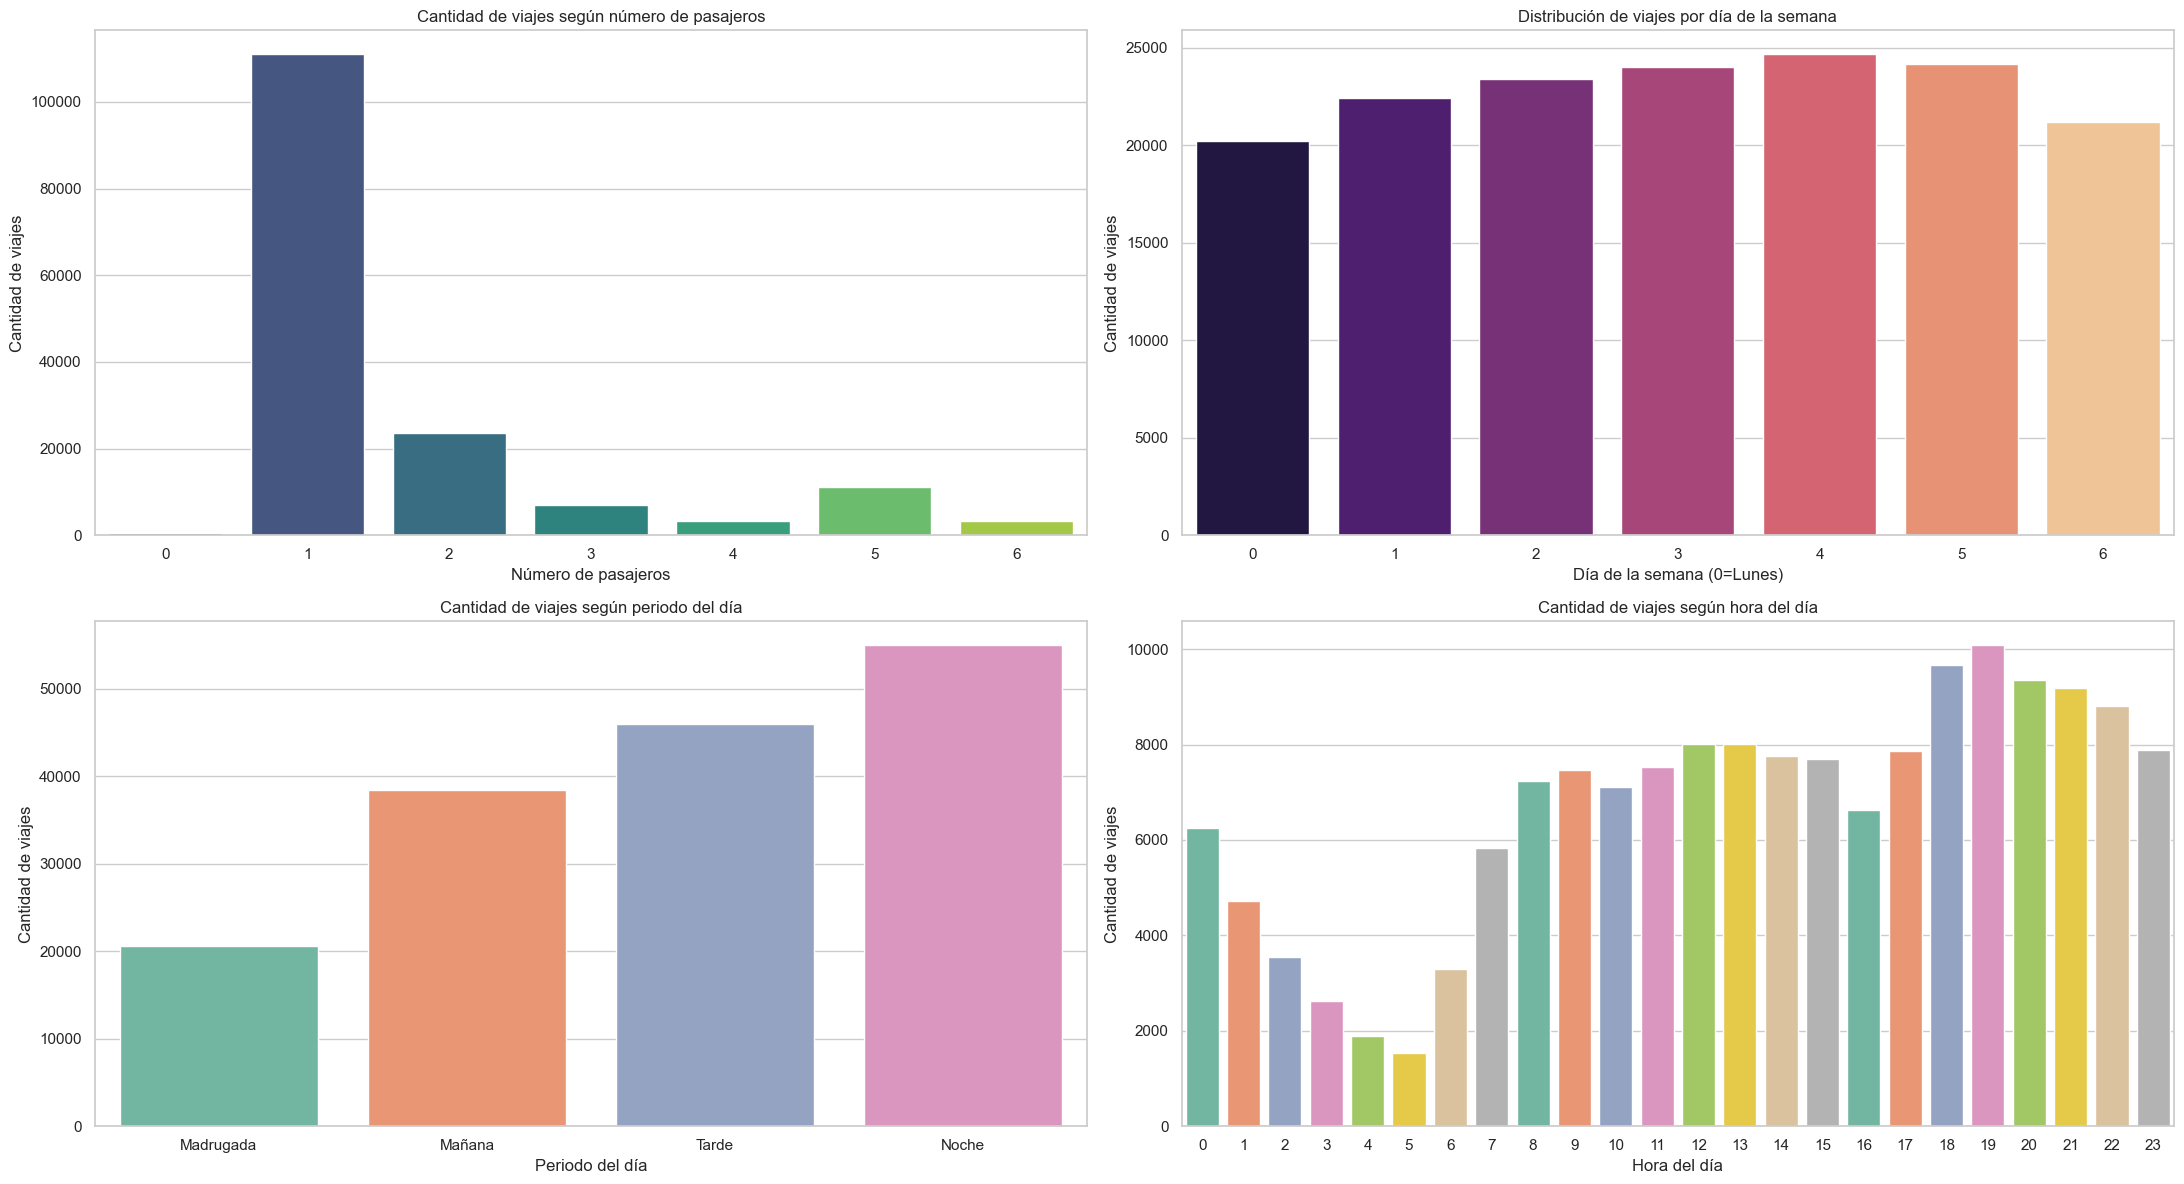

In [230]:
sns.set(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(22, 12))

# Conteo de viajes por cantidad de pasajeros
sns.countplot(data=X_train, x="passenger_count", ax=axes[0,0], palette="viridis")
axes[0,0].set_title("Cantidad de viajes según número de pasajeros")
axes[0,0].set_xlabel("Número de pasajeros")
axes[0,0].set_ylabel("Cantidad de viajes")

# Conteo de viajes por día de la semana
order_days = [0, 1, 2, 3, 4, 5, 6]  # Lunes=0 ... Domingo=6
sns.countplot(data=X_train, x="day_week_num", order=order_days, ax=axes[0,1], palette="magma")
axes[0,1].set_title("Distribución de viajes por día de la semana")
axes[0,1].set_xlabel("Día de la semana (0=Lunes)")
axes[0,1].set_ylabel("Cantidad de viajes")

# Conteo de viajes por franja horaria del día
sns.countplot(
    data=X_train,
    x="period_of_the_day",
    order=["Madrugada", "Mañana", "Tarde", "Noche"],
    ax=axes[1,0],
    palette="Set2"
)
axes[1,0].set_title("Cantidad de viajes según periodo del día")
axes[1,0].set_xlabel("Periodo del día")
axes[1,0].set_ylabel("Cantidad de viajes")

# Conteo de viajes por franja horaria del día
sns.countplot(
    data=X_train,
    x="hora",
    ax=axes[1,1],
    palette="Set2"
)
axes[1,1].set_title("Cantidad de viajes según hora del día")
axes[1,1].set_xlabel("Hora del día")
axes[1,1].set_ylabel("Cantidad de viajes")


plt.tight_layout()
plt.show()

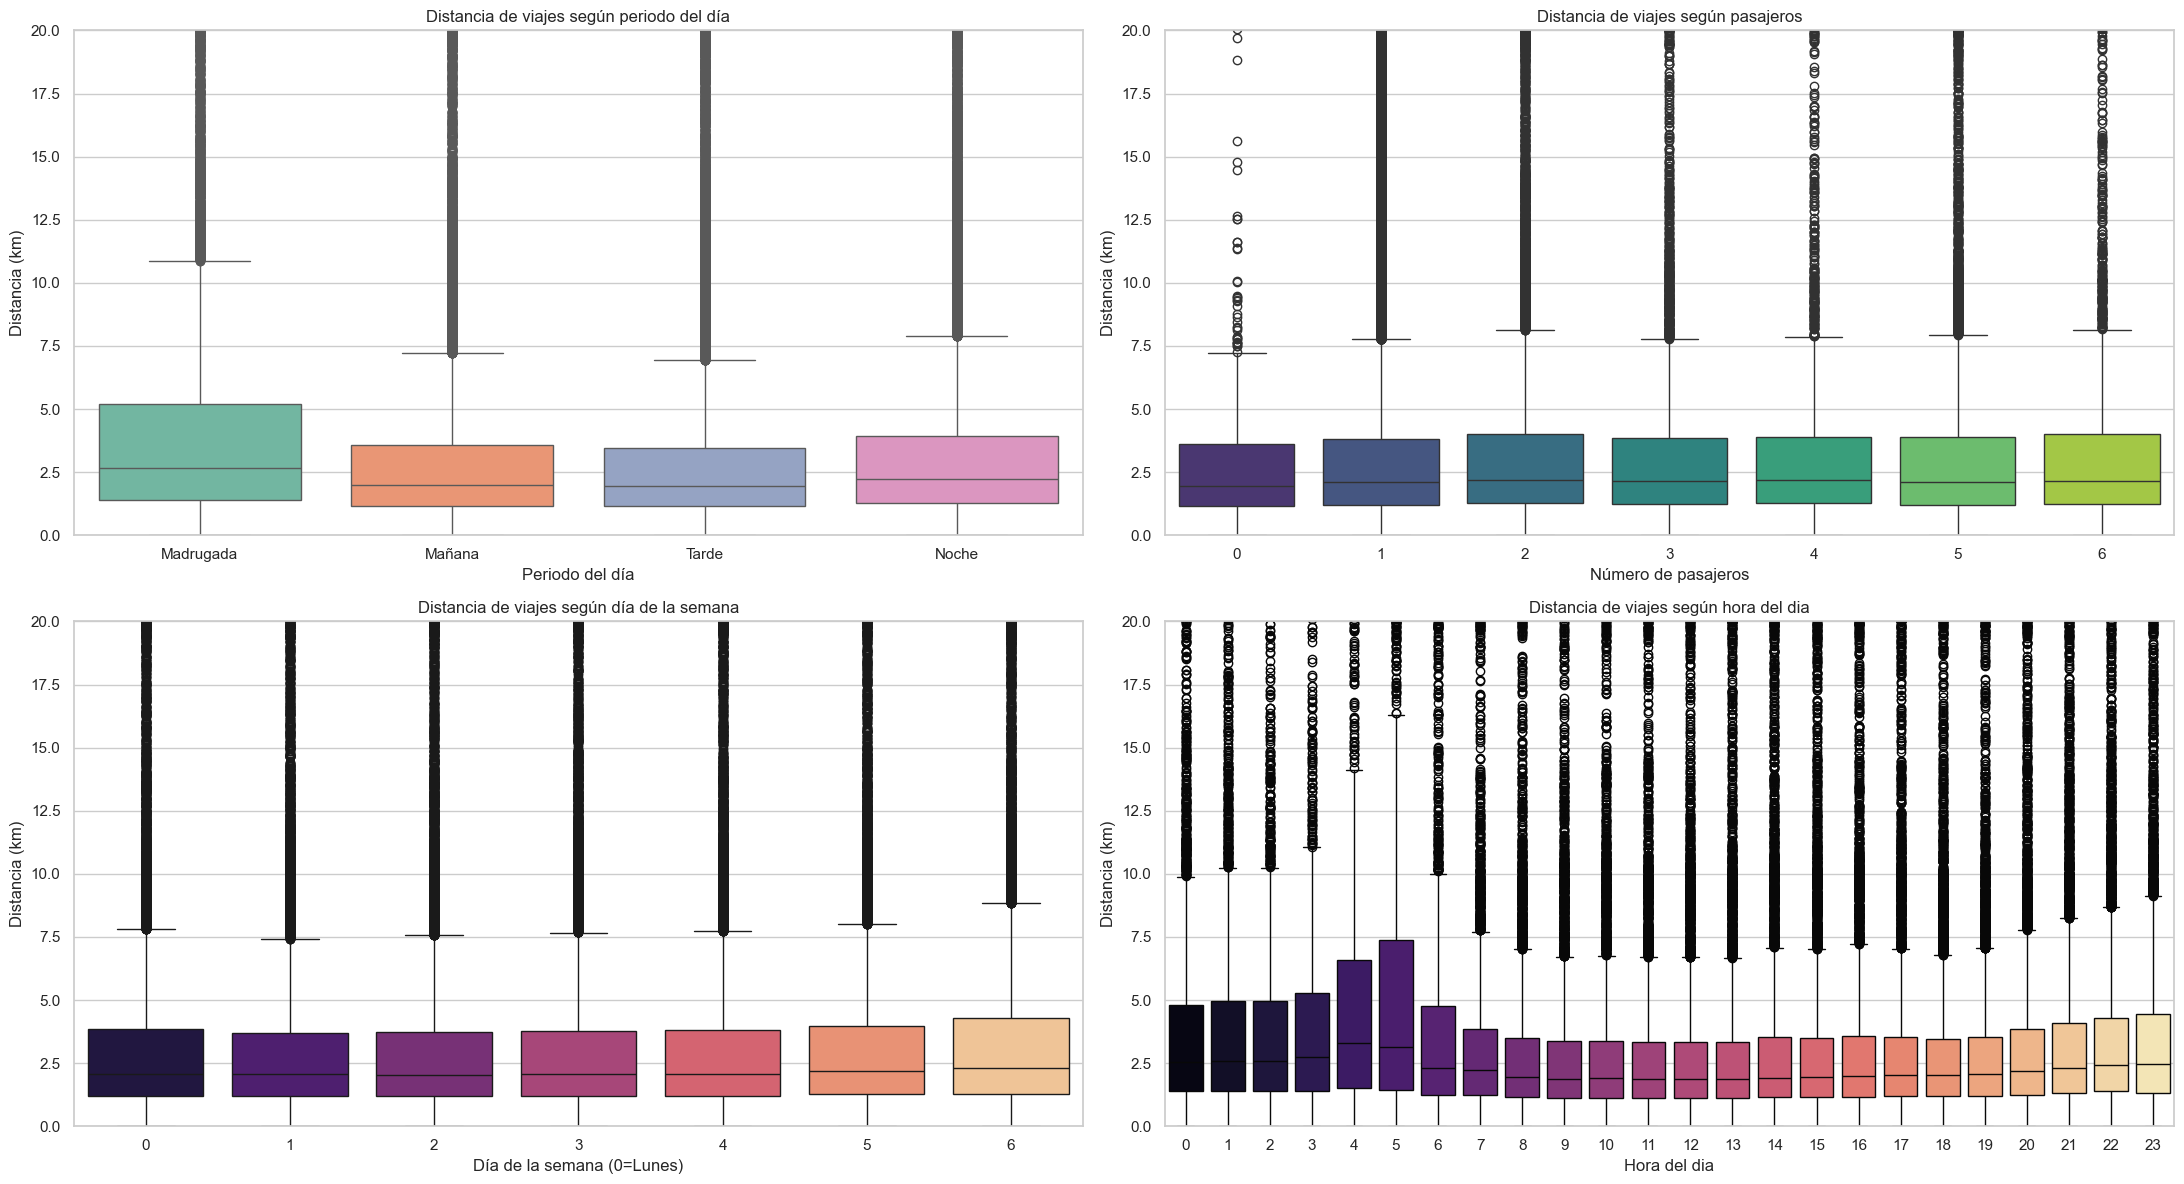

In [231]:
fig, axes = plt.subplots(2, 2, figsize=(22, 12))

# Distancia según periodo del día
sns.boxplot(
    data=X_train,
    x="period_of_the_day",
    y="distancia_km",
    order=["Madrugada", "Mañana", "Tarde", "Noche"],
    ax=axes[0,0],
    palette="Set2"
)
axes[0,0].set_ylim(0, 20)
axes[0,0].set_title("Distancia de viajes según periodo del día")
axes[0,0].set_xlabel("Periodo del día")
axes[0,0].set_ylabel("Distancia (km)")

# Distancia vs número de pasajeros
sns.boxplot(
    data=X_train,
    x="passenger_count",
    y="distancia_km",
    ax=axes[0,1],
    palette="viridis"
)
axes[0,1].set_ylim(0, 20)
axes[0,1].set_title("Distancia de viajes según pasajeros")
axes[0,1].set_xlabel("Número de pasajeros")
axes[0,1].set_ylabel("Distancia (km)")

# Distancia por día de la semana
sns.boxplot(
    data=X_train,
    x="day_week_num",
    y="distancia_km",
    ax=axes[1,0],
    palette="magma"
)
axes[1,0].set_ylim(0, 20)
axes[1,0].set_title("Distancia de viajes según día de la semana")
axes[1,0].set_xlabel("Día de la semana (0=Lunes)")
axes[1,0].set_ylabel("Distancia (km)")

# Distancia por día de la semana
sns.boxplot(
    data=X_train,
    x="hora",
    y="distancia_km",
    ax=axes[1,1],
    palette="magma"
)
axes[1,1].set_ylim(0, 20)
axes[1,1].set_title("Distancia de viajes según hora del dia")
axes[1,1].set_xlabel("Hora del dia")
axes[1,1].set_ylabel("Distancia (km)")


plt.tight_layout()
plt.show()

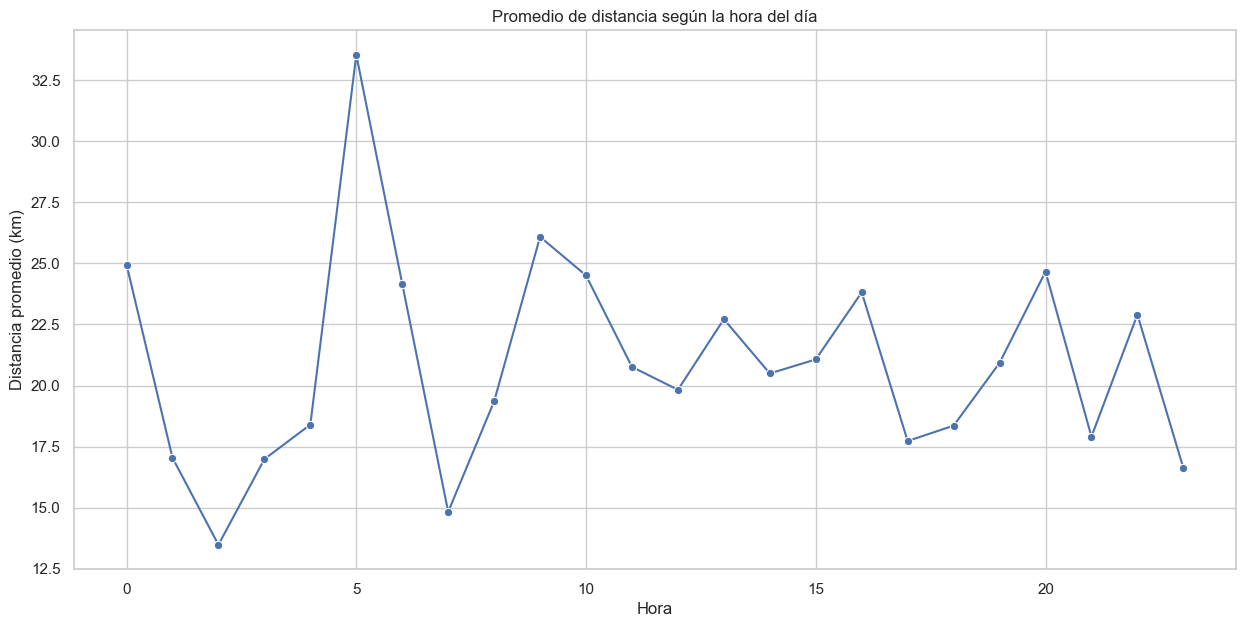

In [232]:
# Promedio de distancia según hora del día

plt.figure(figsize=(15,7))
sns.lineplot(data=X_train, x="hora", y="distancia_km", estimator="mean", ci=None, marker="o")
plt.title("Promedio de distancia según la hora del día")
plt.xlabel("Hora")
plt.ylabel("Distancia promedio (km)")
plt.show()


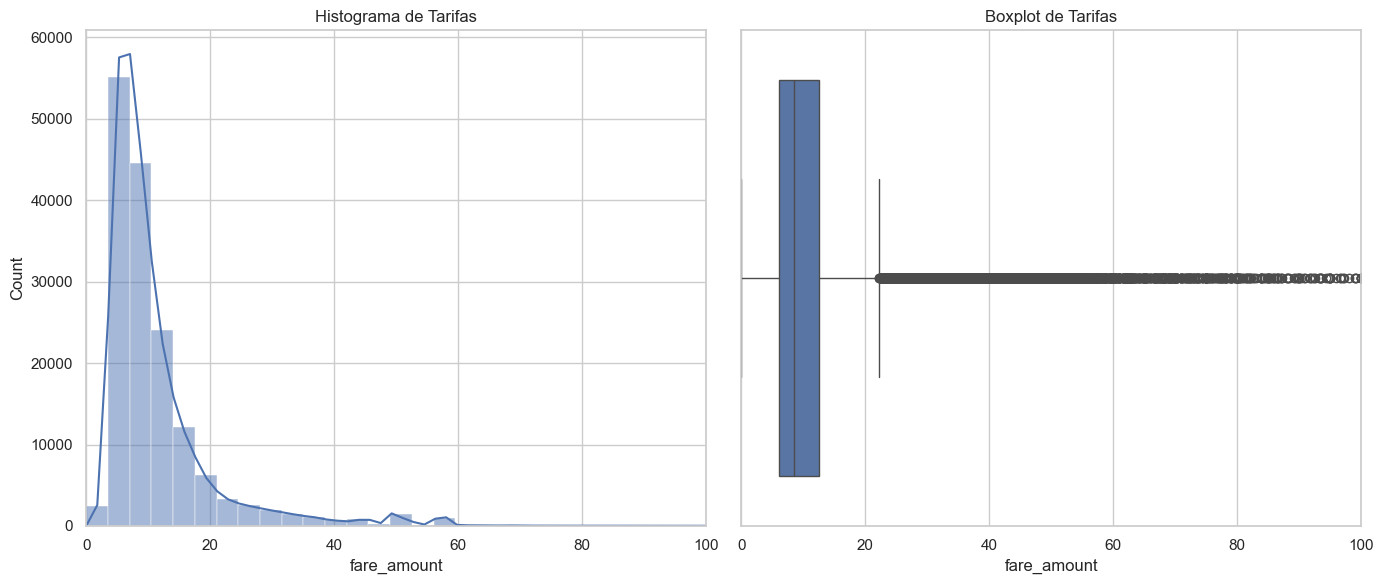

In [233]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histograma de tarifas
sns.histplot(y_train, bins=100, kde=True, ax=axes[0])
axes[0].set_xlim(0, 100)  # límite para ver mejor la zona central
axes[0].set_title("Histograma de Tarifas")

# Boxplot de tarifas
sns.boxplot(x=y_train, ax=axes[1])
axes[1].set_xlim(0, 100)
axes[1].set_title("Boxplot de Tarifas")

plt.tight_layout()
plt.show()

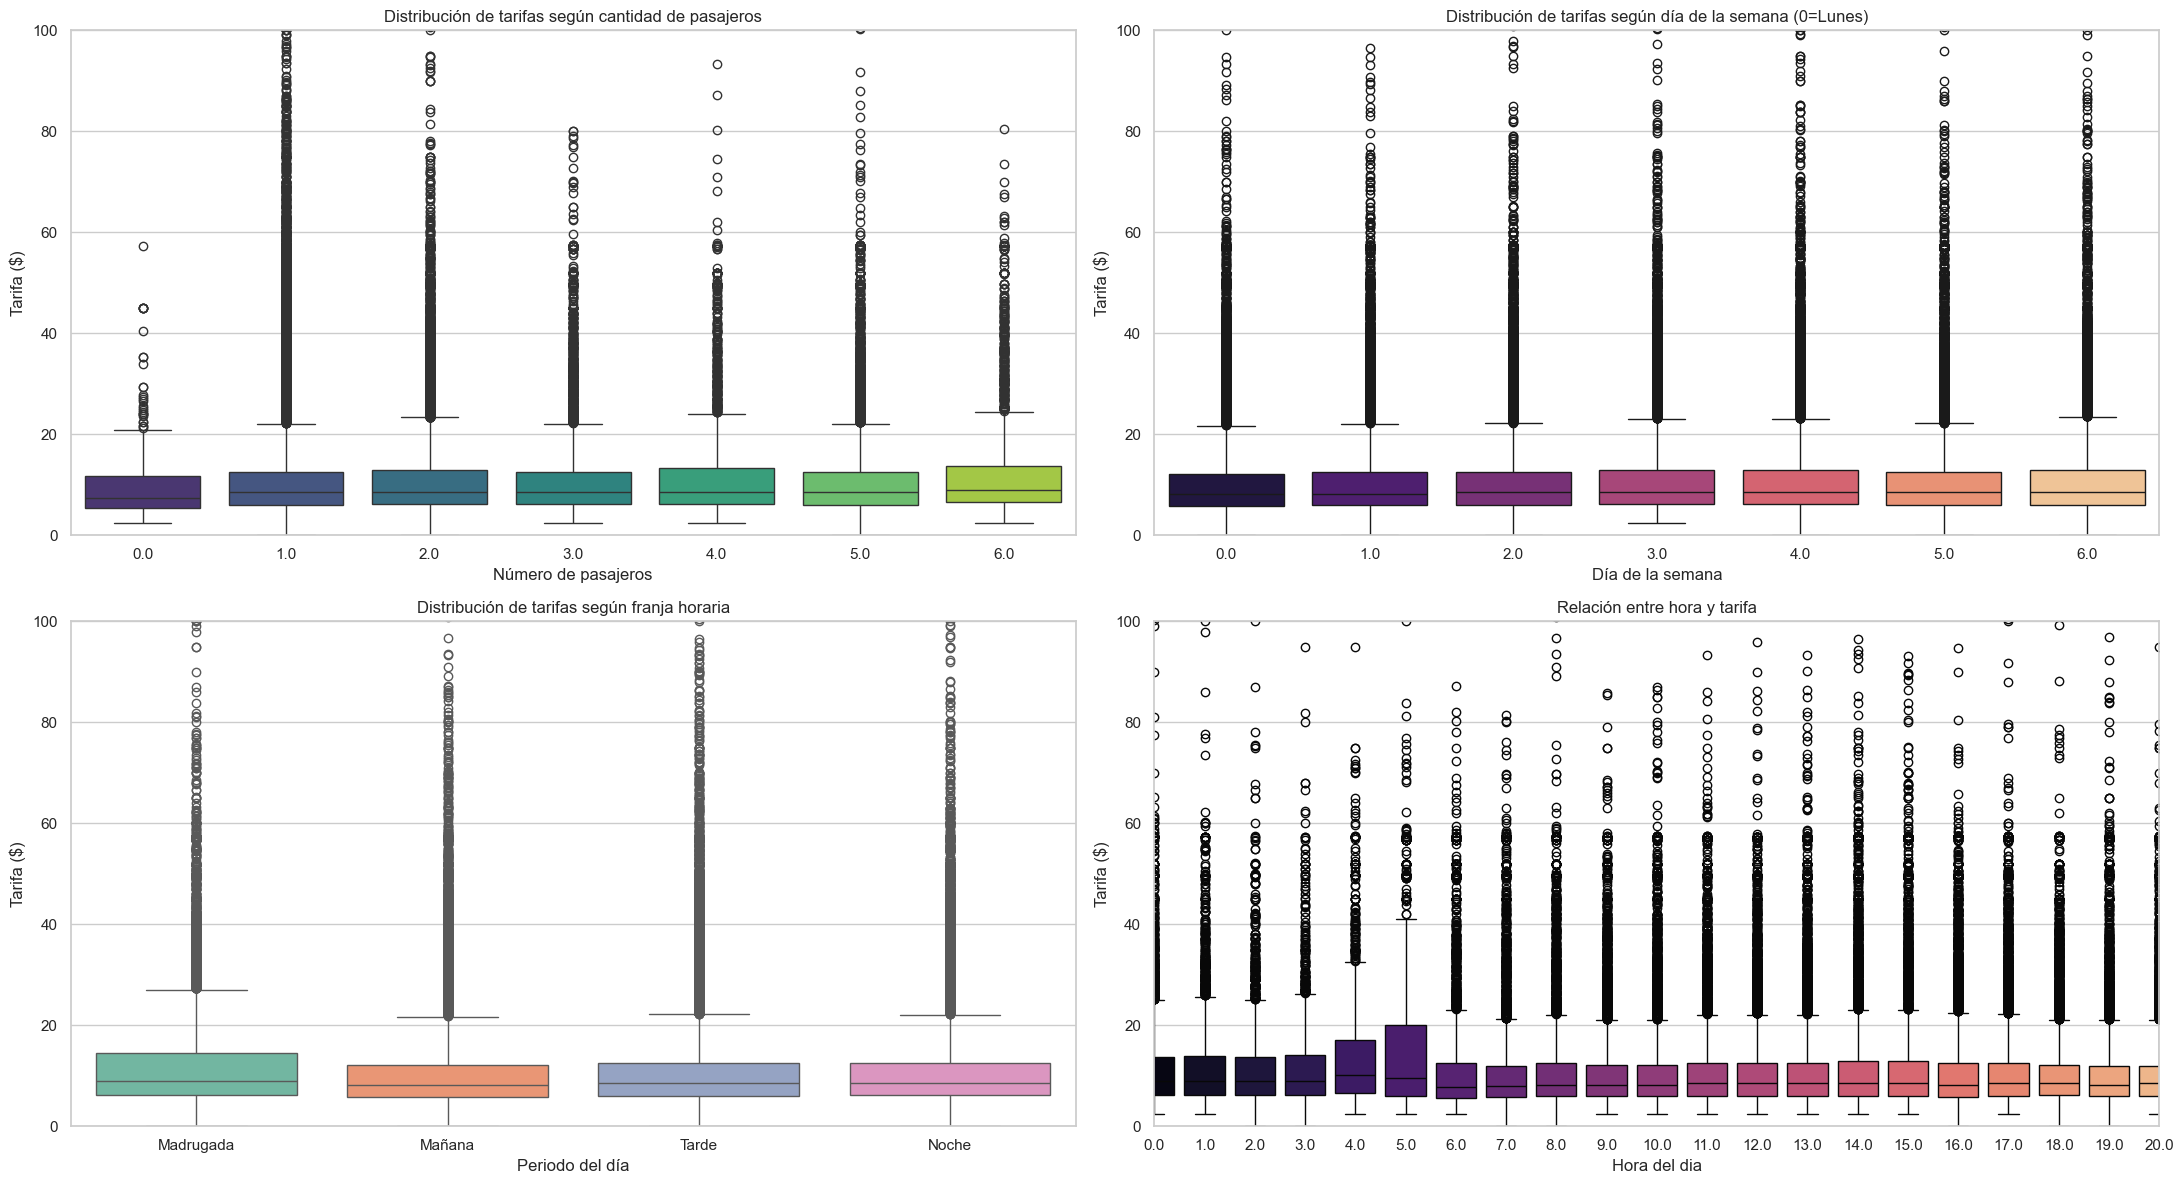

In [234]:
fig, axes = plt.subplots(2, 2, figsize=(22, 12))

# Distribución de tarifas según pasajeros
sns.boxplot(x=X_train["passenger_count"], y=y_train, ax=axes[0,0], palette="viridis")
axes[0,0].set_ylim(0, 100)
axes[0,0].set_title("Distribución de tarifas según cantidad de pasajeros")
axes[0,0].set_xlabel("Número de pasajeros")
axes[0,0].set_ylabel("Tarifa ($)")

# Distribución de tarifas por día de la semana
sns.boxplot(x=X_train["day_week_num"], y=y_train, ax=axes[0,1], palette="magma")
axes[0,1].set_ylim(0, 100)
axes[0,1].set_title("Distribución de tarifas según día de la semana (0=Lunes)")
axes[0,1].set_xlabel("Día de la semana")
axes[0,1].set_ylabel("Tarifa ($)")

# Distribución de tarifas por franja horaria del día
sns.boxplot(x=X_train["period_of_the_day"], y=y_train, 
            order=["Madrugada","Mañana","Tarde","Noche"],
            ax=axes[1,0], palette="Set2")
axes[1,0].set_ylim(0, 100)
axes[1,0].set_title("Distribución de tarifas según franja horaria")
axes[1,0].set_xlabel("Periodo del día")
axes[1,0].set_ylabel("Tarifa ($)")

# Relación entre distancia y tarifa (dispersión)
sns.boxplot(x=X_train["hora"], y=y_train, ax=axes[1,1],palette="magma")
axes[1,1].set_xlim(0, 20)   # limitar a 20 km para evitar outliers extremos
axes[1,1].set_ylim(0, 100)
axes[1,1].set_title("Relación entre hora y tarifa")
axes[1,1].set_xlabel("Hora del dia")
axes[1,1].set_ylabel("Tarifa ($)")


plt.tight_layout()
plt.show()

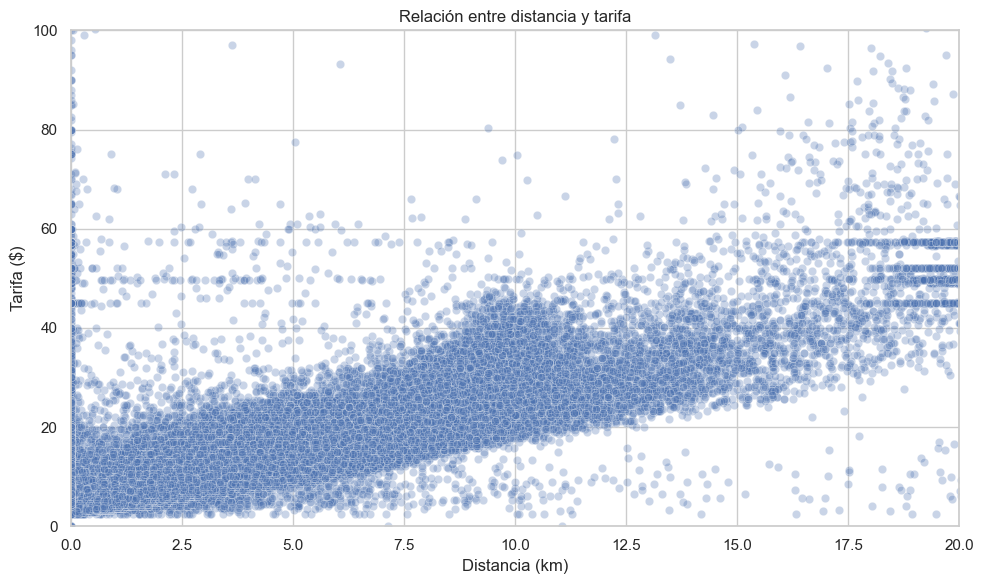

In [235]:
# Relación entre distancia y tarifa (dispersión)
plt.figure(figsize=(10, 6)) 
sns.scatterplot(x=X_train["distancia_km"], y=y_train, alpha=0.3)
plt.xlim(0, 20)   # Limitar a 20 km para evitar outliers extremos
plt.ylim(0, 100)  # Limitar a 100 dólares para evitar outliers extremos
plt.title("Relación entre distancia y tarifa")
plt.xlabel("Distancia (km)")
plt.ylabel("Tarifa ($)")
plt.tight_layout()
plt.show()

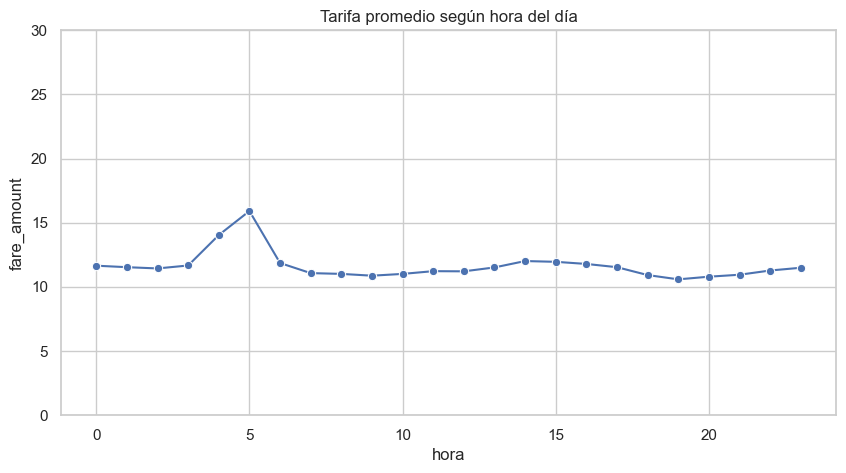

In [236]:
# Fare por hora del día

plt.figure(figsize=(10,5))
sns.lineplot(x=X_train["hora"], y=y_train, estimator="mean", errorbar=None, marker="o")
plt.ylim(0, 30)
plt.title("Tarifa promedio según hora del día")
plt.show()

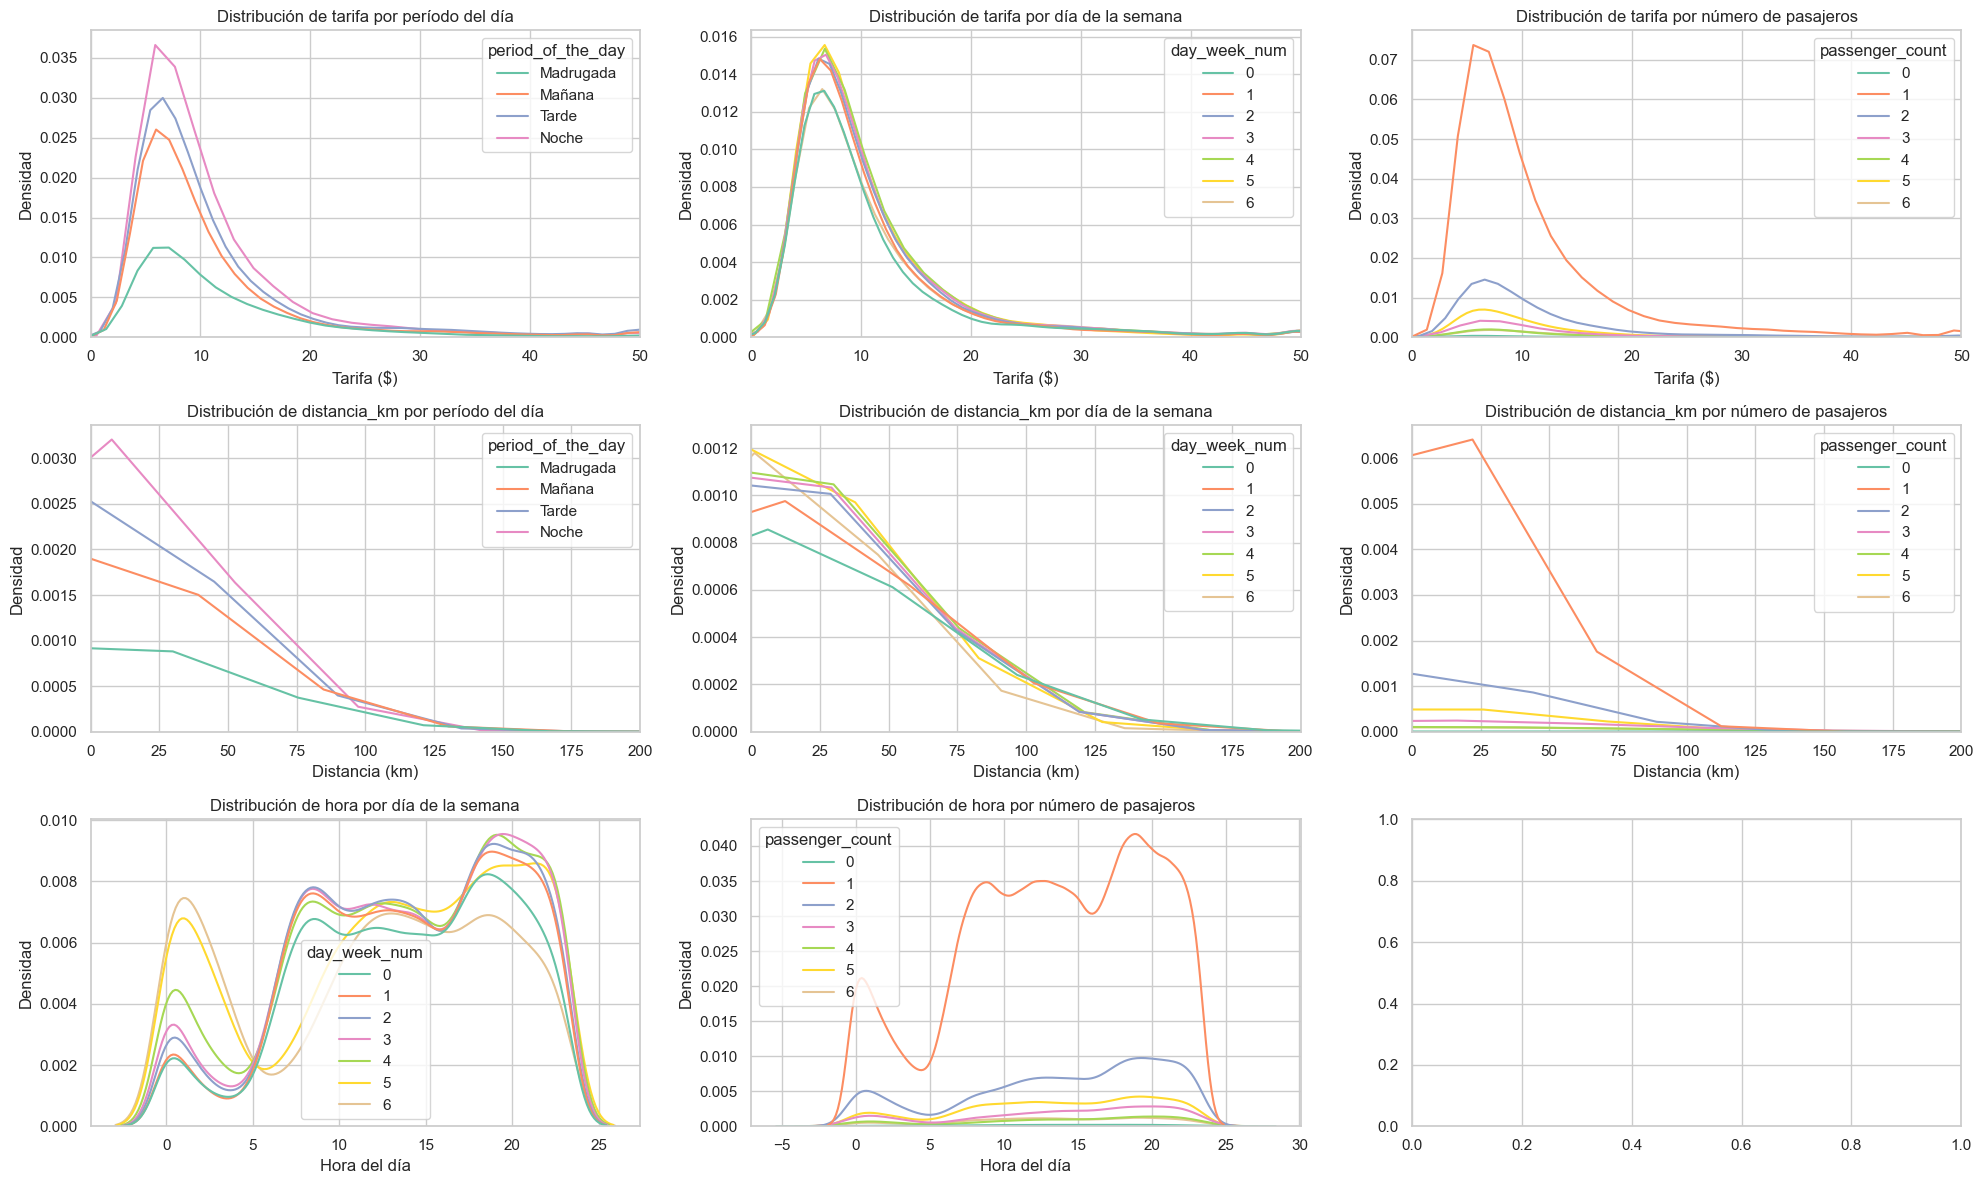

In [312]:
fig, ((ax1, ax2, ax3) ,(ax4, ax5, ax6), (ax7, ax8, ax9)) = plt.subplots(nrows=3, ncols=3, figsize=(20, 12))

# Combinar X_train y y_train para los gráficos de target
data_combined = X_train.copy()
data_combined['target'] = y_train

# Gráfico 1: Distribución de la variable objetivo por período del día
sns.kdeplot(data=data_combined, x='target', hue='period_of_the_day', palette='Set2', ax=ax1)
ax1.set_xlim(0, 50)
ax1.set_title("Distribución de tarifa por período del día")
ax1.set_xlabel("Tarifa ($)")
ax1.set_ylabel("Densidad")

# Gráfico 2: Distribución de la variable objetivo por día de la semana
sns.kdeplot(data=data_combined, x='target', hue='day_week_num', palette='Set2', ax=ax2)
ax2.set_xlim(0, 50)
ax2.set_title("Distribución de tarifa por día de la semana")
ax2.set_xlabel("Tarifa ($)")
ax2.set_ylabel("Densidad")

# Gráfico 3: Distribución de la variable objetivo por número de pasajeros
sns.kdeplot(data=data_combined, x='target', hue='passenger_count', palette='Set2', ax=ax3)
ax3.set_xlim(0, 50)
ax3.set_title("Distribución de tarifa por número de pasajeros")
ax3.set_xlabel("Tarifa ($)")
ax3.set_ylabel("Densidad")

# Gráfico 4: Distribución de distancia_km por período del día
sns.kdeplot(data=X_train, x='distancia_km', hue='period_of_the_day', palette='Set2', ax=ax4)
ax4.set_xlim(0, 200)
ax4.set_title("Distribución de distancia_km por período del día")
ax4.set_xlabel("Distancia (km)")
ax4.set_ylabel("Densidad")

# Gráfico 5: Distribución de distancia_km por día de la semana
sns.kdeplot(data=X_train, x='distancia_km', hue='day_week_num', palette='Set2', ax=ax5)
ax5.set_xlim(0, 200)
ax5.set_title("Distribución de distancia_km por día de la semana")
ax5.set_xlabel("Distancia (km)")
ax5.set_ylabel("Densidad")

# Gráfico 6: Distribución de distancia_km por número de pasajeros
sns.kdeplot(data=X_train, x='distancia_km', hue='passenger_count', palette='Set2', ax=ax6)
ax6.set_xlim(0, 200)
ax6.set_title("Distribución de distancia_km por número de pasajeros")
ax6.set_xlabel("Distancia (km)")
ax6.set_ylabel("Densidad")

# Gráfico 7: Distribución de hora por día de la semana
sns.kdeplot(data=X_train, x='hora', hue='day_week_num', palette='Set2', ax=ax7)
ax7.set_title("Distribución de hora por día de la semana")
ax7.set_xlabel("Hora del día")
ax7.set_ylabel("Densidad")

# Gráfico 8: Distribución de hora por número de pasajeros
sns.kdeplot(data=X_train, x='hora', hue='passenger_count', palette='Set2', ax=ax8)
ax8.set_title("Distribución de hora por número de pasajeros")
ax8.set_xlabel("Hora del día")
ax8.set_ylabel("Densidad")

plt.tight_layout()
plt.show()

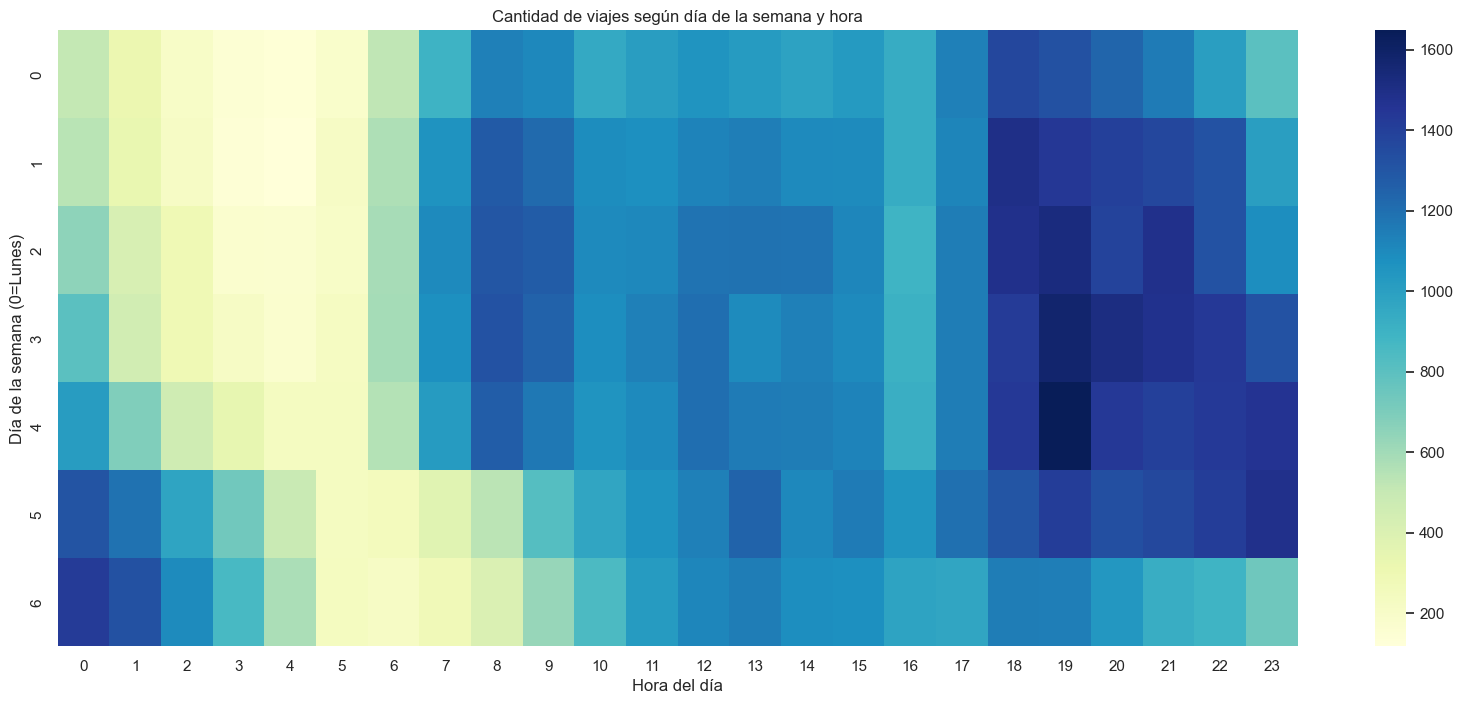

In [320]:
# Heatmap hora vs día de la semana

pivot_data = X_train.groupby(['day_week_num','hora']).size().unstack(fill_value=0)
plt.figure(figsize=(20,8))
sns.heatmap(pivot_data, cmap="YlGnBu")
plt.title("Cantidad de viajes según día de la semana y hora")
plt.xlabel("Hora del día")
plt.ylabel("Día de la semana (0=Lunes)")
plt.show()

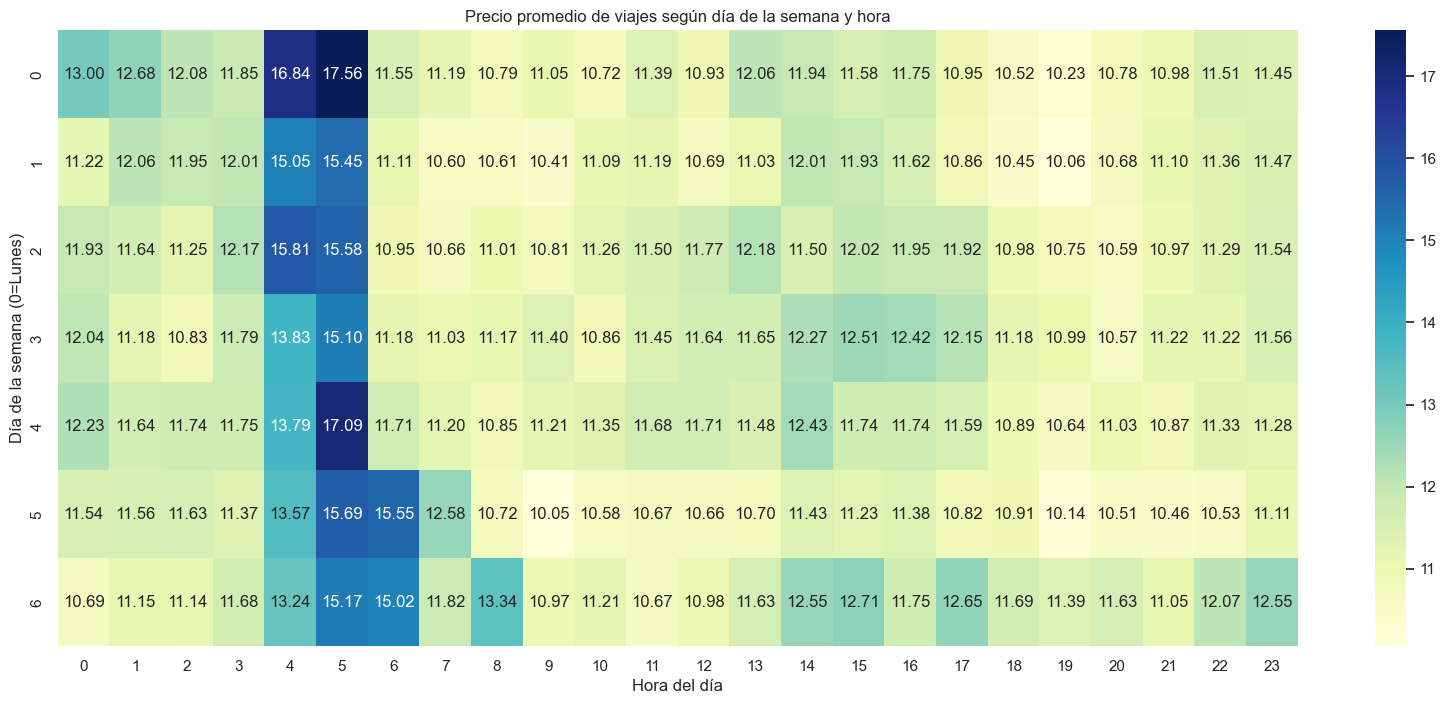

In [ ]:
# Heatmap precio promedio vs día de la semana y hora

# Combinar X_train y y_train
data_combined = X_train[['day_week_num', 'hora']].copy()
data_combined['target'] = y_train

# Agrupar por día de la semana y hora, y calcular el precio promedio
pivot_data = data_combined.groupby(['day_week_num', 'hora'])['target'].mean().unstack(fill_value=0)

plt.figure(figsize=(20, 8))
sns.heatmap(pivot_data, cmap="YlGnBu", annot=True, fmt=".2f")
plt.title("Precio promedio de viajes según día de la semana y hora")
plt.xlabel("Hora del día")
plt.ylabel("Día de la semana (0=Lunes)")
plt.show()

## Correlaciones

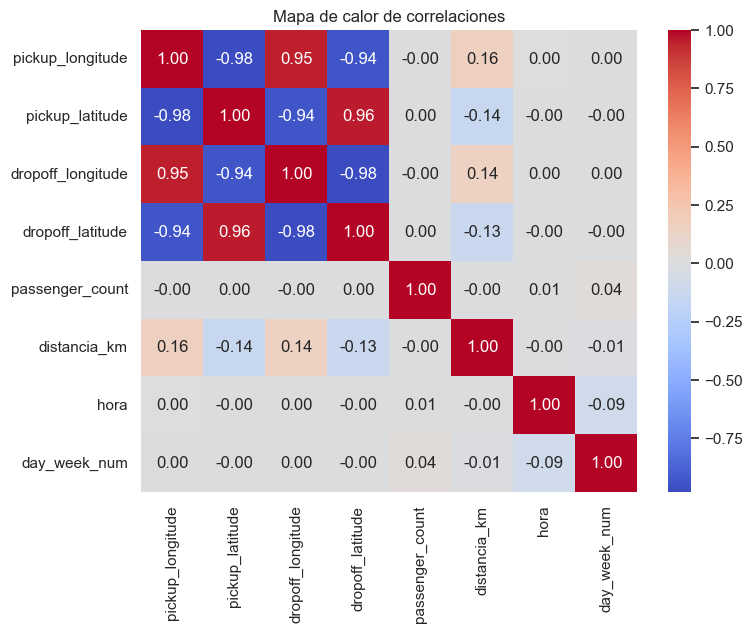

In [238]:
# Heatmap de correlaciones numéricas

plt.figure(figsize=(8,6))
corr = X_train[['pickup_longitude','pickup_latitude',
                'dropoff_longitude','dropoff_latitude',
                'passenger_count','distancia_km','hora','day_week_num']].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Mapa de calor de correlaciones")
plt.show()

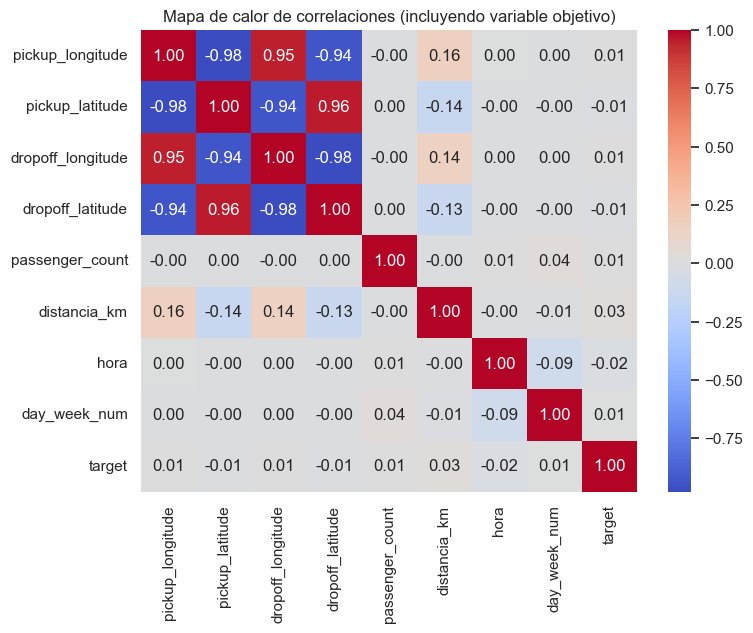

In [ ]:
# Mapa de correlaciones incluyendo variable objetivo

data_combined = X_train[['pickup_longitude', 'pickup_latitude', 
                         'dropoff_longitude', 'dropoff_latitude', 
                         'passenger_count', 'distancia_km', 'hora', 
                         'day_week_num']].copy()
data_combined['target'] = y_train

corr = data_combined.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Mapa de calor de correlaciones (incluyendo variable objetivo)")
plt.show()

## Escalado

In [239]:
X_train

,key,date,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distancia_km,day_week_num,fecha_hora,hora,period_of_the_day
48971,34596106,2015-01-06 16:30:04.0000002,2015-01-06 16:30:04 UTC,-73.996948,40.737476,-74.005592,40.738586,1,0.738675,1,2015-01-06 16:30:04.000000200+00:00,16,Tarde
131208,2147393,2012-01-07 15:22:25.0000001,2012-01-07 15:22:25 UTC,-73.993049,40.759392,-73.990639,40.751125,1,0.941397,5,2012-01-07 15:22:25.000000100+00:00,15,Tarde
15045,50775201,2010-04-16 15:17:00.000000204,2010-04-16 15:17:00 UTC,-73.989005,40.758418,-73.870420,40.773570,2,10.128021,4,2010-04-16 15:17:00.000000204+00:00,15,Tarde
11426,17264957,2009-12-31 23:39:28.0000009,2009-12-31 23:39:28 UTC,-73.991654,40.733589,-73.985400,40.745320,4,1.406828,3,2009-12-31 23:39:28.000000900+00:00,23,Noche
49247,30842630,2009-07-06 20:52:00.00000023,2009-07-06 20:52:00 UTC,-73.967235,40.788065,-73.985768,40.747167,2,4.808030,0,2009-07-06 20:52:00.000000230+00:00,20,Noche
...,...,...,...,...,...,...,...,...,...,...,...,...,...
119887,23426202,2014-10-30 08:33:00.000000109,2014-10-30 08:33:00 UTC,-73.885343,40.773065,-73.973907,40.784050,1,7.556580,3,2014-10-30 08:33:00.000000109+00:00,8,Mañana
103701,21290919,2013-05-17 10:40:00.000000199,2013-05-17 10:40:00 UTC,-73.992142,40.749410,-74.015142,40.709645,1,4.827759,4,2013-05-17 10:40:00.000000199+00:00,10,Mañana
131940,34840847,2009-11-08 14:37:00.000000205,2009-11-08 14:37:00 UTC,-73.992528,40.714083,-73.992703,40.728007,1,1.548351,6,2009-11-08 14:37:00.000000205+00:00,14,Tarde
146877,16683017,2009-11-14 03:27:22.0000002,2009-11-14 03:27:22 UTC,-73.985502,40.768050,-73.950450,40.775060,1,3.052921,5,2009-11-14 03:27:22.000000200+00:00,3,Madrugada


In [245]:
# eliminar columnas key, date
X_train_limpio = X_train.drop(['key', 'date', 'fecha_hora','pickup_datetime'], axis=1)
X_test_limpio = X_test.drop(['key', 'date','pickup_datetime'], axis=1)

In [250]:
label_encoder = LabelEncoder()

X_train_limpio['period_of_the_day'] = label_encoder.fit_transform(X_train_limpio['period_of_the_day'])

# Verificar los resultados
print(X_train_limpio['period_of_the_day'].head())
print(label_encoder.classes_)  

48971     3
131208    3
15045     3
11426     2
49247     2
Name: period_of_the_day, dtype: int64
['Madrugada' 'Mañana' 'Noche' 'Tarde']


In [251]:
X_train_limpio

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distancia_km,day_week_num,hora,period_of_the_day
48971,-73.996948,40.737476,-74.005592,40.738586,1,0.738675,1,16,3
131208,-73.993049,40.759392,-73.990639,40.751125,1,0.941397,5,15,3
15045,-73.989005,40.758418,-73.870420,40.773570,2,10.128021,4,15,3
11426,-73.991654,40.733589,-73.985400,40.745320,4,1.406828,3,23,2
49247,-73.967235,40.788065,-73.985768,40.747167,2,4.808030,0,20,2
...,...,...,...,...,...,...,...,...,...
119887,-73.885343,40.773065,-73.973907,40.784050,1,7.556580,3,8,1
103701,-73.992142,40.749410,-74.015142,40.709645,1,4.827759,4,10,1
131940,-73.992528,40.714083,-73.992703,40.728007,1,1.548351,6,14,3
146877,-73.985502,40.768050,-73.950450,40.775060,1,3.052921,5,3,0


In [252]:
# Utilizamos escalado robusto
scaler=RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_limpio)
X_test_scaled = scaler.fit_transform(X_test_limpio)